# SNO 预测与圆环解析解对比

本 Notebook 针对

$[
\Delta P-k^2P=0,
\qquad P(r_{\mathrm{out}},\theta)=0,
\qquad -P_r(r_{\mathrm{in}},\theta)=\cos\theta
]$

恢复训练完成的 Function Encoder 与 Operator Learner，仅加载模型参数进行推理，并将 SNO 预测与解析解比较。

主要输出：

- 网格相对 \(L_2\)、面积加权相对 \(L_2\)、相对 \(L_\infty\) 与 RMSE；
- 外边界 Dirichlet 误差和内边界 Neumann 通量误差；
- 2 行 × 3 列科研图：第一行笛卡尔视图，第二行极坐标视图；三列依次为 SNO、解析解、绝对误差；
- SVG、PDF、PNG、NPZ 和 JSON 结果文件。

## 1. Goal 与图形契约

**核心结论**：检验训练后的 SNO 是否能在整个圆环区域重构零源项、余弦法向通量问题的解析压力场。

- 图形类型：定量网格（quantitative grid）。
- 证据链：预测场 → 解析场 → 点态绝对误差。
- 色标规则：预测与解析解严格共享同一对称色标；误差使用独立的非负色标。
- 坐标规则：笛卡尔与极坐标两行使用完全相同的数据和色标。
- 审查风险：避免不同色标造成视觉误判；误差指标同时给出网格范数和带面积元 \(r\,dr\,d\theta\) 的物理范数。
- 后端：Python / matplotlib；SVG 为主输出，PDF 和 PNG 为辅助输出。

## 2. Setup

In [1]:
# 必须在导入 JAX 之前设置。按服务器实际 GPU 编号修改。
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

GPU_ID = "5"
os.environ["CUDA_VISIBLE_DEVICES"] = GPU_ID
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
# 如需进一步限制显存，可取消下一行注释：
# os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.85"

print("CUDA_VISIBLE_DEVICES =", os.environ["CUDA_VISIBLE_DEVICES"])

CUDA_VISIBLE_DEVICES = 5


In [2]:
from dataclasses import fields
from pathlib import Path
import json
import sys

import jax
import jax.numpy as jnp
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from flax import serialization
from IPython.display import Markdown, display

PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "config_polar.py").exists():
    PROJECT_DIR = Path("/home/user/data/Hollon/海洋工程水动力/polar_annulus_sno_code")

if not (PROJECT_DIR / "config_polar.py").exists():
    raise FileNotFoundError("PROJECT_DIR 中找不到 config_polar.py，请修改项目路径。")

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from config_polar import PolarAnnulusConfig
from data_polar import (
    make_condition_tokens_from_arrays,
    make_source_tokens,
    make_target_cosine_boundary,
    normalize_f,
    r_to_hat,
    theta_to_hat,
)
from exact_solution import exact_annulus_solution
from models_polar import FunctionEncoder, OperatorTransformer
from train_polar import load_normalizer

print("Project directory:", PROJECT_DIR)
print("JAX version:", jax.__version__)
print("JAX devices:", jax.devices())

Project directory: D:\A4S\海洋工程动水力-机器学习\polar_annulus_sno_code
JAX version: 0.10.2
JAX devices: [CpuDevice(id=0)]


### 2.1 用户参数

In [3]:
RUN_NAME = "polar_v3"
K_VALUE = 1.0

# 连续 FE 解码网格。数值均为单元中心，适合 pcolormesh。
PLOT_RADIAL_CELLS = 128
PLOT_THETA_CELLS = 256
DECODE_CHUNK_SIZE = 8192

OUTPUT_ROOT = PROJECT_DIR / "out_polar_annulus_sno"
RUN_DIR = OUTPUT_ROOT / RUN_NAME
EVAL_DIR = RUN_DIR / "sno_exact_evaluation"
EVAL_DIR.mkdir(parents=True, exist_ok=True)

print("Run directory:", RUN_DIR)
print("Evaluation directory:", EVAL_DIR)

Run directory: D:\A4S\海洋工程动水力-机器学习\polar_annulus_sno_code\out_polar_annulus_sno\polar_v3
Evaluation directory: D:\A4S\海洋工程动水力-机器学习\polar_annulus_sno_code\out_polar_annulus_sno\polar_v3\sno_exact_evaluation


## 3. Steps

### 3.1 恢复训练配置

In [4]:
config_path = RUN_DIR / "config.json"
if not config_path.exists():
    raise FileNotFoundError(f"找不到训练配置：{config_path}")

saved_config = json.loads(config_path.read_text(encoding="utf-8"))
valid_fields = {field.name for field in fields(PolarAnnulusConfig)}
config_kwargs = {
    key: value
    for key, value in saved_config.items()
    if key in valid_fields
}

# JSON 会把 tuple 保存成 list；恢复为不可变结构以保持配置语义一致。
if "prior_scale_pairs" in config_kwargs:
    config_kwargs["prior_scale_pairs"] = tuple(
        tuple(pair) for pair in config_kwargs["prior_scale_pairs"]
    )
for key in ("cnn_channels", "cnn_kernel_size", "cnn_stride"):
    if key in config_kwargs:
        config_kwargs[key] = tuple(config_kwargs[key])

# 兼容重构前的旧 config.json。
config_kwargs.setdefault("ol_log_interval", 500)
config_kwargs.setdefault("ol_checkpoint_interval", 10_000)
config_kwargs.setdefault("ol_eval_sample_size", 16)
config_kwargs.setdefault("ol_eval_probe_points", 256)
config_kwargs["out_dir"] = str(OUTPUT_ROOT)
config_kwargs["run_name"] = RUN_NAME

cfg = PolarAnnulusConfig(**config_kwargs)

if not cfg.k_min <= K_VALUE <= cfg.k_max:
    raise ValueError(
        f"K_VALUE={K_VALUE} 超出训练范围 [{cfg.k_min}, {cfg.k_max}]。"
    )
if K_VALUE < 0:
    raise ValueError("解析解的实数实现要求 K_VALUE >= 0。")
if PLOT_RADIAL_CELLS < 2 or PLOT_THETA_CELLS < 8:
    raise ValueError("绘图网格过小。")
if DECODE_CHUNK_SIZE <= 0:
    raise ValueError("DECODE_CHUNK_SIZE 必须为正整数。")

print(
    f"Geometry: r in [{cfg.r_inner}, {cfg.r_outer}], "
    f"theta cells={cfg.theta_size}, radial cells={cfg.radial_size}"
)
print(f"Trained k range: [{cfg.k_min}, {cfg.k_max}]")
print("Evaluation k:", K_VALUE)

Geometry: r in [0.2, 1.0], theta cells=128, radial cells=32
Trained k range: [1.0, 1.0]
Evaluation k: 1.0


### 3.2 选择 checkpoint 并仅加载参数

In [5]:
fe_checkpoint = RUN_DIR / "fe_params.msgpack"
ol_final_checkpoint = RUN_DIR / "ol_params.msgpack"
ol_latest_checkpoint = RUN_DIR / "ol_params_latest.msgpack"

if not fe_checkpoint.exists():
    raise FileNotFoundError(f"找不到 FE checkpoint：{fe_checkpoint}")

if ol_final_checkpoint.exists():
    ol_checkpoint = ol_final_checkpoint
    ol_checkpoint_status = "final"
elif ol_latest_checkpoint.exists():
    ol_checkpoint = ol_latest_checkpoint
    ol_checkpoint_status = "latest fallback"
else:
    raise FileNotFoundError(
        "找不到 ol_params.msgpack 或 ol_params_latest.msgpack。"
    )

print("FE checkpoint:", fe_checkpoint)
print("OL checkpoint:", ol_checkpoint)
print("OL checkpoint status:", ol_checkpoint_status)
if ol_checkpoint_status != "final":
    print("WARNING: 未找到最终 checkpoint，当前使用 latest checkpoint。")

FE checkpoint: D:\A4S\海洋工程动水力-机器学习\polar_annulus_sno_code\out_polar_annulus_sno\polar_v3\fe_params.msgpack
OL checkpoint: D:\A4S\海洋工程动水力-机器学习\polar_annulus_sno_code\out_polar_annulus_sno\polar_v3\ol_params_latest.msgpack
OL checkpoint status: latest fallback


In [6]:
def load_params_only(path: Path):
    """Restore a Flax parameter pytree without constructing optimizer state."""
    restored = serialization.msgpack_restore(path.read_bytes())
    return jax.tree_util.tree_map(jnp.asarray, restored)


fe_params = load_params_only(fe_checkpoint)
ol_params = load_params_only(ol_checkpoint)
normalizer = load_normalizer(RUN_DIR)

fe_model = FunctionEncoder(cfg)
ol_model = OperatorTransformer(cfg)

fe_parameter_count = sum(x.size for x in jax.tree_util.tree_leaves(fe_params))
ol_parameter_count = sum(x.size for x in jax.tree_util.tree_leaves(ol_params))

print(f"FE parameters: {fe_parameter_count:,}")
print(f"OL parameters: {ol_parameter_count:,}")
print(
    "Normalizer:",
    f"std_P={float(normalizer.std_p):.6e}",
    f"mean_f={float(normalizer.mean_f):.6e}",
    f"std_f={float(normalizer.std_f):.6e}",
)

FE parameters: 70,053,888
OL parameters: 13,991,936
Normalizer: std_P=4.162077e-01 mean_f=-5.124479e-03 std_f=1.334440e+01


### 3.3 SNO 推理：$(f=0)$，$(g_n=\cos	\theta)$

In [7]:
zero_f = jnp.zeros((1, cfg.n_pod), dtype=jnp.float32)
latent_f = fe_model.apply(
    {"params": fe_params},
    normalize_f(zero_f, normalizer),
    method=FunctionEncoder.encode_f,
)
f_tokens = make_source_tokens(latent_f, cfg)

boundary_coords, boundary_flux = make_target_cosine_boundary(cfg, batch_size=1)
boundary_tokens = make_condition_tokens_from_arrays(
    boundary_coords,
    boundary_flux,
    cfg,
)
k_values = jnp.asarray([K_VALUE], dtype=jnp.float32)

pred_latent_p = ol_model.apply(
    {"params": ol_params},
    f_tokens,
    boundary_tokens,
    k_values,
)
jax.block_until_ready(pred_latent_p)

assert pred_latent_p.shape == (1, cfg.n_basis)
assert bool(jnp.all(jnp.isfinite(pred_latent_p)))
print("Predicted pressure latent shape:", pred_latent_p.shape)

Predicted pressure latent shape: (1, 512)


### 3.4 在连续高分辨率网格上分块解码

In [8]:
r_edges = np.linspace(
    cfg.r_inner,
    cfg.r_outer,
    PLOT_RADIAL_CELLS + 1,
    dtype=np.float64,
)
theta_edges = np.linspace(
    0.0,
    2.0 * np.pi,
    PLOT_THETA_CELLS + 1,
    dtype=np.float64,
)
r_centers = 0.5 * (r_edges[:-1] + r_edges[1:])
theta_centers = 0.5 * (theta_edges[:-1] + theta_edges[1:])
rr, tt = np.meshgrid(r_centers, theta_centers, indexing="ij")

coords_hat = np.stack(
    [
        np.asarray(theta_to_hat(jnp.asarray(tt))),
        np.asarray(r_to_hat(jnp.asarray(rr), cfg)),
    ],
    axis=-1,
).reshape(-1, 2).astype(np.float32)


@jax.jit
def decode_pressure_chunk(params, latent, coords):
    return fe_model.apply(
        {"params": params},
        latent,
        coords,
        method=FunctionEncoder.reconstruct_p,
    )


decoded_chunks = []
for start in range(0, coords_hat.shape[0], DECODE_CHUNK_SIZE):
    stop = min(start + DECODE_CHUNK_SIZE, coords_hat.shape[0])
    chunk = jnp.asarray(coords_hat[start:stop])
    decoded_chunks.append(
        decode_pressure_chunk(fe_params, pred_latent_p, chunk)
    )

p_pred_norm_flat = jnp.concatenate(decoded_chunks, axis=1)
p_pred_flat = (
    p_pred_norm_flat * normalizer.std_p + normalizer.mean_p
)
jax.block_until_ready(p_pred_flat)

p_pred = np.asarray(p_pred_flat[0]).reshape(
    PLOT_RADIAL_CELLS,
    PLOT_THETA_CELLS,
)

assert p_pred.shape == rr.shape
assert np.all(np.isfinite(p_pred))
print("Dense decoded field shape:", p_pred.shape)

Dense decoded field shape: (128, 256)


### 3.5 解析解与误差指标

In [9]:
p_exact = exact_annulus_solution(
    rr,
    tt,
    K_VALUE,
    r_inner=cfg.r_inner,
    r_outer=cfg.r_outer,
)
signed_error = p_pred - p_exact
absolute_error = np.abs(signed_error)


def relative_l2(pred, ref, weights=None):
    pred = np.asarray(pred, dtype=np.float64)
    ref = np.asarray(ref, dtype=np.float64)
    if weights is None:
        numerator = np.sum((pred - ref) ** 2)
        denominator = np.sum(ref**2)
    else:
        weights = np.asarray(weights, dtype=np.float64)
        numerator = np.sum(weights * (pred - ref) ** 2)
        denominator = np.sum(weights * ref**2)
    return float(np.sqrt(numerator / max(denominator, np.finfo(float).tiny)))


grid_relative_l2 = relative_l2(p_pred, p_exact)
area_relative_l2 = relative_l2(p_pred, p_exact, weights=rr)
rmse = float(np.sqrt(np.mean(signed_error**2)))
max_absolute_error = float(np.max(absolute_error))
relative_linf = max_absolute_error / max(
    float(np.max(np.abs(p_exact))),
    np.finfo(float).tiny,
)

metrics = {
    "k_value": float(K_VALUE),
    "grid_relative_l2": grid_relative_l2,
    "area_weighted_relative_l2": area_relative_l2,
    "relative_linf": float(relative_linf),
    "rmse": rmse,
    "max_absolute_error": max_absolute_error,
}

for name, value in metrics.items():
    print(f"{name:30s}: {value:.8e}")

k_value                       : 1.00000000e+00
grid_relative_l2              : 1.05512354e-01
area_weighted_relative_l2     : 1.33386611e-01
relative_linf                 : 6.89514437e-02
rmse                          : 5.00547684e-03
max_absolute_error            : 1.20868485e-02


## 4. Checks

In [10]:
# 外边界 P=0：使用连续 FE 解码器直接评价 r_hat=1。
theta_boundary = jnp.asarray(theta_centers, dtype=jnp.float32)
outer_coords_hat = jnp.stack(
    [theta_to_hat(theta_boundary), jnp.ones_like(theta_boundary)],
    axis=-1,
)
outer_p_norm = decode_pressure_chunk(
    fe_params,
    pred_latent_p,
    outer_coords_hat,
)
outer_p = outer_p_norm * normalizer.std_p + normalizer.mean_p
outer_dirichlet_max_abs = float(jnp.max(jnp.abs(outer_p)))


# 内边界 g_n=-P_r：对连续解码器做自动微分，不使用有限差分。
def decoded_pressure_scalar(params, latent, coord_hat):
    p_norm = fe_model.apply(
        {"params": params},
        latent,
        coord_hat[None, :],
        method=FunctionEncoder.reconstruct_p,
    )[0, 0]
    return p_norm * normalizer.std_p + normalizer.mean_p


pressure_gradient = jax.jit(
    jax.vmap(
        jax.grad(decoded_pressure_scalar, argnums=2),
        in_axes=(None, None, 0),
    )
)
inner_coords_hat = jnp.stack(
    [theta_to_hat(theta_boundary), -jnp.ones_like(theta_boundary)],
    axis=-1,
)
grad_hat = pressure_gradient(fe_params, pred_latent_p, inner_coords_hat)
pred_inner_flux = -grad_hat[:, 1] * cfg.drhat_dr
true_inner_flux = jnp.cos(theta_boundary)
inner_flux_relative_l2 = float(
    jnp.linalg.norm(pred_inner_flux - true_inner_flux)
    / jnp.maximum(jnp.linalg.norm(true_inner_flux), 1.0e-12)
)

metrics["outer_dirichlet_max_abs"] = outer_dirichlet_max_abs
metrics["inner_flux_relative_l2"] = inner_flux_relative_l2

assert np.all(np.isfinite(p_exact)), "解析解包含 NaN/Inf"
assert np.all(np.isfinite(absolute_error)), "误差包含 NaN/Inf"
assert np.isfinite(inner_flux_relative_l2), "内边界通量指标不是有限数"

print(f"Outer Dirichlet max |P| : {outer_dirichlet_max_abs:.8e}")
print(f"Inner flux relative L2  : {inner_flux_relative_l2:.8e}")

Outer Dirichlet max |P| : 0.00000000e+00
Inner flux relative L2  : 2.40504652e-01


## 5. Results：2 × 3 笛卡尔/极坐标对比

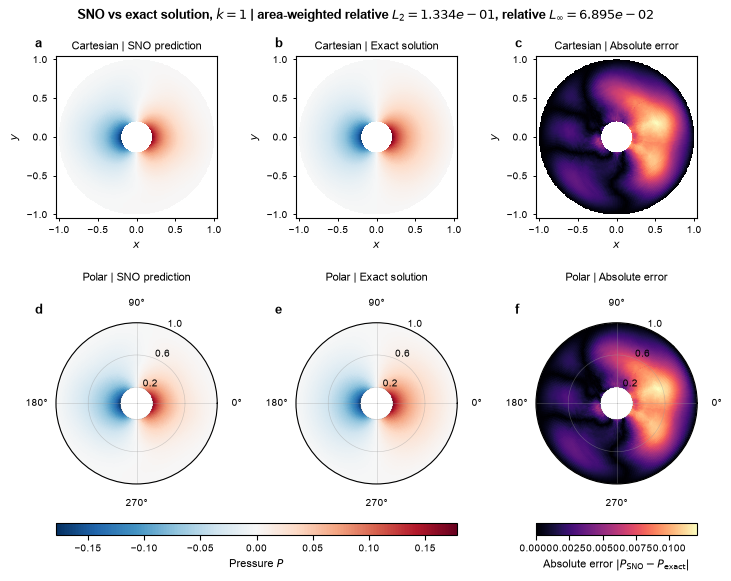

In [11]:
mpl.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "DejaVu Sans", "Liberation Sans"],
        "svg.fonttype": "none",
        "pdf.fonttype": 42,
        "font.size": 8,
        "axes.titlesize": 8,
        "axes.labelsize": 8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "axes.linewidth": 0.8,
    }
)

solution_limit = max(
    float(np.max(np.abs(p_pred))),
    float(np.max(np.abs(p_exact))),
    np.finfo(float).eps,
)
error_limit = max(float(np.max(absolute_error)), np.finfo(float).eps)
solution_norm = mpl.colors.TwoSlopeNorm(
    vmin=-solution_limit,
    vcenter=0.0,
    vmax=solution_limit,
)
error_norm = mpl.colors.Normalize(vmin=0.0, vmax=error_limit)

rr_edges, tt_edges = np.meshgrid(r_edges, theta_edges, indexing="ij")
x_edges = rr_edges * np.cos(tt_edges)
y_edges = rr_edges * np.sin(tt_edges)

fig = plt.figure(figsize=(7.2, 5.7), layout="constrained")
grid = fig.add_gridspec(
    3,
    3,
    height_ratios=(1.0, 1.0, 0.055),
)
axes = [
    fig.add_subplot(grid[0, 0]),
    fig.add_subplot(grid[0, 1]),
    fig.add_subplot(grid[0, 2]),
    fig.add_subplot(grid[1, 0], projection="polar"),
    fig.add_subplot(grid[1, 1], projection="polar"),
    fig.add_subplot(grid[1, 2], projection="polar"),
]

fields = [p_pred, p_exact, absolute_error]
titles_top = ["SNO prediction", "Exact solution", "Absolute error"]
titles_bottom = ["SNO prediction", "Exact solution", "Absolute error"]
panel_labels = list("abcdef")

cartesian_meshes = []
for index, (ax, field, title) in enumerate(zip(axes[:3], fields, titles_top)):
    is_error = index == 2
    mesh = ax.pcolormesh(
        x_edges,
        y_edges,
        field,
        shading="flat",
        cmap="magma" if is_error else "RdBu_r",
        norm=error_norm if is_error else solution_norm,
        rasterized=True,
    )
    cartesian_meshes.append(mesh)
    ax.set_aspect("equal")
    margin = 1.04 * cfg.r_outer
    ax.set_xlim(-margin, margin)
    ax.set_ylim(-margin, margin)
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$y$")
    ax.set_title(f"Cartesian | {title}", pad=5)
    ax.tick_params(direction="out", length=2.5, width=0.7)
    ax.text(
        -0.13,
        1.04,
        panel_labels[index],
        transform=ax.transAxes,
        fontsize=9,
        fontweight="bold",
        va="bottom",
    )

polar_meshes = []
for local_index, (ax, field, title) in enumerate(
    zip(axes[3:], fields, titles_bottom)
):
    is_error = local_index == 2
    mesh = ax.pcolormesh(
        theta_edges,
        r_edges,
        field,
        shading="flat",
        cmap="magma" if is_error else "RdBu_r",
        norm=error_norm if is_error else solution_norm,
        rasterized=True,
    )
    polar_meshes.append(mesh)
    ax.set_ylim(0.0, cfg.r_outer)
    ax.set_theta_zero_location("E")
    ax.set_theta_direction(1)
    ax.set_thetagrids([0, 90, 180, 270])
    ax.set_rticks([cfg.r_inner, 0.5 * (cfg.r_inner + cfg.r_outer), cfg.r_outer])
    ax.set_rlabel_position(67.5)
    ax.grid(color="#9A9A9A", linewidth=0.45, alpha=0.45)
    ax.set_title(f"Polar | {title}", pad=13)
    ax.text(
        -0.13,
        1.04,
        panel_labels[local_index + 3],
        transform=ax.transAxes,
        fontsize=9,
        fontweight="bold",
        va="bottom",
    )

solution_colorbar_axis = fig.add_subplot(grid[2, 0:2])
error_colorbar_axis = fig.add_subplot(grid[2, 2])
solution_colorbar = fig.colorbar(
    cartesian_meshes[0],
    cax=solution_colorbar_axis,
    orientation="horizontal",
)
solution_colorbar.set_label(r"Pressure $P$")
error_colorbar = fig.colorbar(
    cartesian_meshes[2],
    cax=error_colorbar_axis,
    orientation="horizontal",
)
error_colorbar.set_label(
    r"Absolute error $|P_{\mathrm{SNO}}-P_{\mathrm{exact}}|$"
)

fig.suptitle(
    rf"SNO vs exact solution, $k={K_VALUE:g}$ | "
    rf"area-weighted relative $L_2={area_relative_l2:.3e}$, "
    rf"relative $L_\infty={relative_linf:.3e}$",
    fontsize=9,
    fontweight="bold",
)

figure_base = EVAL_DIR / f"sno_vs_exact_k_{K_VALUE:g}"
figure_paths = []
# for extension, options in {
#     "svg": {},
#     "pdf": {},
#     "png": {"dpi": 300},
# }.items():
#     path = figure_base.with_suffix(f".{extension}")
#     fig.savefig(path, bbox_inches="tight", facecolor="white", **options)
#     figure_paths.append(path)

plt.show()
plt.close(fig)

# for path in figure_paths:
#     print("Saved figure:", path)

### 5.1 径向与周向剖面对比

径向剖面在 $θ=0,π/2,π,3π/2$ 处比较；周向剖面在 $r=0.2,0.4,0.6,0.8$ 处比较。颜色表示角度或半径，实线和虚线分别表示 SNO 预测与解析解。

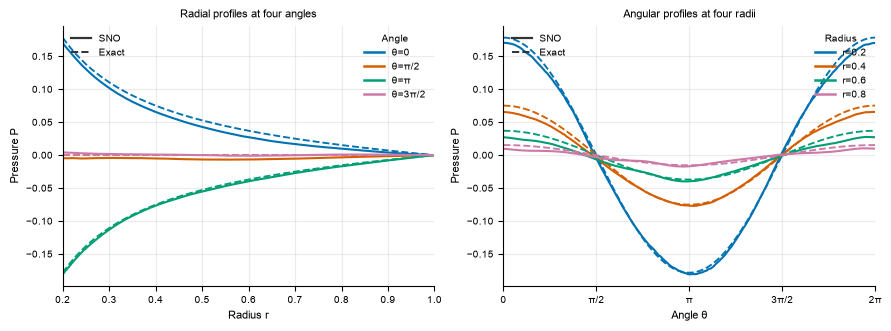

In [12]:
from matplotlib.lines import Line2D


def decode_pressure_at(radius, angle):
    """Decode dimensional pressure at matching physical coordinates."""
    radius = np.asarray(radius, dtype=np.float32)
    angle = np.asarray(angle, dtype=np.float32)
    if radius.shape != angle.shape:
        raise ValueError("radius and angle must have the same shape.")

    profile_coords_hat = np.stack(
        [
            np.asarray(theta_to_hat(jnp.asarray(angle))),
            np.asarray(r_to_hat(jnp.asarray(radius), cfg)),
        ],
        axis=-1,
    ).reshape(-1, 2).astype(np.float32)

    decoded_host_chunks = []
    for start in range(0, profile_coords_hat.shape[0], DECODE_CHUNK_SIZE):
        stop = min(start + DECODE_CHUNK_SIZE, profile_coords_hat.shape[0])
        decoded = decode_pressure_chunk(
            fe_params,
            pred_latent_p,
            jnp.asarray(profile_coords_hat[start:stop]),
        )
        decoded_host_chunks.append(np.asarray(jax.device_get(decoded))[0])

    pressure_norm = np.concatenate(decoded_host_chunks)
    pressure_mean = float(jax.device_get(normalizer.mean_p))
    pressure_std = float(jax.device_get(normalizer.std_p))
    return (pressure_norm * pressure_std + pressure_mean).reshape(radius.shape)


radial_profile_angles = np.asarray(
    [0.0, 0.5 * np.pi, np.pi, 1.5 * np.pi],
    dtype=np.float32,
)
radial_angle_labels = ["0", "π/2", "π", "3π/2"]
radial_profile_r = np.linspace(
    cfg.r_inner,
    cfg.r_outer,
    PLOT_RADIAL_CELLS + 1,
    dtype=np.float32,
)
radial_rr, radial_tt = np.meshgrid(
    radial_profile_r,
    radial_profile_angles,
    indexing="ij",
)
radial_pred = decode_pressure_at(radial_rr, radial_tt)
radial_exact = exact_annulus_solution(
    radial_rr,
    radial_tt,
    K_VALUE,
    r_inner=cfg.r_inner,
    r_outer=cfg.r_outer,
)

angular_profile_radii = np.asarray(
    [0.2, 0.4, 0.6, 0.8],
    dtype=np.float32,
)
if np.any(angular_profile_radii < cfg.r_inner) or np.any(
    angular_profile_radii > cfg.r_outer
):
    raise ValueError(
        f"Requested radii must lie in [{cfg.r_inner}, {cfg.r_outer}]."
    )
angular_profile_theta = np.linspace(
    0.0,
    2.0 * np.pi,
    PLOT_THETA_CELLS + 1,
    dtype=np.float32,
)
angular_rr, angular_tt = np.meshgrid(
    angular_profile_radii,
    angular_profile_theta,
    indexing="ij",
)
angular_pred = decode_pressure_at(angular_rr, angular_tt)
angular_exact = exact_annulus_solution(
    angular_rr,
    angular_tt,
    K_VALUE,
    r_inner=cfg.r_inner,
    r_outer=cfg.r_outer,
)

profile_colors = ["#0072B2", "#D55E00", "#009E73", "#CC79A7"]
profile_figure, profile_axes = plt.subplots(
    1,
    2,
    figsize=(8.8, 3.2),
    layout="constrained",
)

for index, color in enumerate(profile_colors):
    profile_axes[0].plot(
        radial_profile_r,
        radial_pred[:, index],
        color=color,
        lw=1.5,
    )
    profile_axes[0].plot(
        radial_profile_r,
        radial_exact[:, index],
        color=color,
        ls="--",
        lw=1.35,
    )
    profile_axes[1].plot(
        angular_profile_theta,
        angular_pred[index],
        color=color,
        lw=1.5,
    )
    profile_axes[1].plot(
        angular_profile_theta,
        angular_exact[index],
        color=color,
        ls="--",
        lw=1.35,
    )

profile_axes[0].set(
    xlim=(cfg.r_inner, cfg.r_outer),
    xlabel="Radius r",
    ylabel="Pressure P",
    title="Radial profiles at four angles",
)
profile_axes[1].set(
    xlim=(0.0, 2.0 * np.pi),
    xlabel="Angle θ",
    ylabel="Pressure P",
    title="Angular profiles at four radii",
)
profile_axes[1].set_xticks(
    [0.0, 0.5 * np.pi, np.pi, 1.5 * np.pi, 2.0 * np.pi],
    ["0", "π/2", "π", "3π/2", "2π"],
)

angle_handles = [
    Line2D([0], [0], color=color, lw=1.8, label=f"θ={label}")
    for label, color in zip(radial_angle_labels, profile_colors)
]
radius_handles = [
    Line2D([0], [0], color=color, lw=1.8, label=f"r={radius:.1f}")
    for radius, color in zip(angular_profile_radii, profile_colors)
]
style_handles = [
    Line2D([0], [0], color="0.2", lw=1.6, label="SNO"),
    Line2D(
        [0],
        [0],
        color="0.2",
        ls="--",
        lw=1.4,
        label="Exact",
    ),
]

for axis, value_handles, value_title in zip(
    profile_axes,
    [angle_handles, radius_handles],
    ["Angle", "Radius"],
):
    axis.grid(alpha=0.25)
    axis.spines[["top", "right"]].set_visible(False)
    value_legend = axis.legend(
        handles=value_handles,
        title=value_title,
        loc="upper right",
        frameon=False,
        fontsize=7,
        title_fontsize=7,
    )
    axis.add_artist(value_legend)
    axis.legend(
        handles=style_handles,
        loc="upper left",
        frameon=False,
        fontsize=7,
    )

# profile_base = EVAL_DIR / f"sno_vs_exact_k_{K_VALUE:g}_profiles"
# for extension, options in {
#     "svg": {},
#     "pdf": {},
#     "png": {"dpi": 300},
# }.items():
#     profile_path = profile_base.with_suffix(f".{extension}")
#     profile_figure.savefig(
#         profile_path,
#         bbox_inches="tight",
#         facecolor="white",
#         **options,
#     )
#     print("Saved profile figure:", profile_path)

plt.show()
plt.close(profile_figure)

### 5.2 保存数值结果与指标

In [13]:
npz_path = EVAL_DIR / f"sno_vs_exact_k_{K_VALUE:g}.npz"
metrics_path = EVAL_DIR / f"sno_vs_exact_k_{K_VALUE:g}_metrics.json"

np.savez_compressed(
    npz_path,
    r=r_centers,
    theta=theta_centers,
    x=rr * np.cos(tt),
    y=rr * np.sin(tt),
    p_sno=p_pred,
    p_exact=p_exact,
    signed_error=signed_error,
    absolute_error=absolute_error,
    pred_inner_flux=np.asarray(pred_inner_flux),
    exact_inner_flux=np.asarray(true_inner_flux),
)
metrics_path.write_text(
    json.dumps(metrics, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

print("Saved arrays:", npz_path)
print("Saved metrics:", metrics_path)

Saved arrays: D:\A4S\海洋工程动水力-机器学习\polar_annulus_sno_code\out_polar_annulus_sno\polar_v3\sno_exact_evaluation\sno_vs_exact_k_1.npz
Saved metrics: D:\A4S\海洋工程动水力-机器学习\polar_annulus_sno_code\out_polar_annulus_sno\polar_v3\sno_exact_evaluation\sno_vs_exact_k_1_metrics.json


## 6. Takeaways

In [14]:
checkpoint_note = (
    "最终 checkpoint"
    if ol_checkpoint_status == "final"
    else "latest checkpoint（未发现最终 checkpoint）"
)

display(
    Markdown(
        f"""
本次评估使用 **{checkpoint_note}**，测试参数为 $k={K_VALUE:g}$。

- 网格相对 $L_2$：**{grid_relative_l2:.4e}**
- 面积加权相对 $L_2$：**{area_relative_l2:.4e}**
- 相对 $L_\infty$：**{relative_linf:.4e}**
- RMSE：**{rmse:.4e}**
- 外边界最大绝对误差：**{outer_dirichlet_max_abs:.4e}**
- 内边界通量相对 $L_2$：**{inner_flux_relative_l2:.4e}**

图中的预测解与解析解使用同一色标，因此两者可以直接视觉比较；误差列使用独立非负色标显示误差的空间分布。
"""
    )
)


本次评估使用 **latest checkpoint（未发现最终 checkpoint）**，测试参数为 $k=1$。

- 网格相对 $L_2$：**1.0551e-01**
- 面积加权相对 $L_2$：**1.3339e-01**
- 相对 $L_\infty$：**6.8951e-02**
- RMSE：**5.0055e-03**
- 外边界最大绝对误差：**0.0000e+00**
- 内边界通量相对 $L_2$：**2.4050e-01**

图中的预测解与解析解使用同一色标，因此两者可以直接视觉比较；误差列使用独立非负色标显示误差的空间分布。


## 7. Next Steps

- 若训练覆盖多个 \(k\)，修改 `K_VALUE` 后从“恢复训练配置”单元重新运行。
- 若只有 `ol_params_latest.msgpack`，Notebook 会继续评估，但这并不等价于确认训练循环正常执行到了最后一步。
- 如果 GPU 显存不足，优先减小 `DECODE_CHUNK_SIZE`；这不会改变数值结果。
- 如需更平滑的出版图，可增大 `PLOT_RADIAL_CELLS` 和 `PLOT_THETA_CELLS`，同时保持分块解码。